In [1]:
import pyscrew
import numpy as np
import pandas as pd
import torch.nn as nn
import torch
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import math
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from torch.utils.data import random_split


## Wichtigste Fragen: 
- Ich hatte schon immer und habe sie nach wie vor probleme beim korrekten parametrisieren von NN (korrigieren der loss curves) - ich hätte gerne abhilfe erhalten
- mu als nn.parameters einbinden

Mein Plan: Ich will über die 3. step_value: "Tightening" das Anziehdrehmoment berechnen und dieses dann mittels loss integrieren. \
Das heisst ich muss irgendwie den reibkoeffizienten tan_mu_dkr = mu für die jeweilige klasse erhalten und \
ich muss irgendwie auf die step_values zugreifen können. Damit ich sagen kann: hier drauf achten wie es sich verhält im loss \

- Reibwert mu: in model schreiben: self.mu=nn.Parameter(torch.tensor([0.1, 0.1, 0.1, 0.1, 0.1])) | und dann später im training mu = model.mu[y_batch] | und diese mu dann in loss einbauen physloss = pde_MA_loss(phys_output, mu) ? 
- Wie kann ich nur die final tightening phase X mit dem Anziehdrehungsmoment (physloss) verlgiechen? Über step_value aber wie kriege ich das integriert wenn es nicht im dataset ist (wurde ja randomized und gesplittet)


## Nächste Überlegungen:
- Das furchmoment (2. tightening phase) - schier unmöglich wegen bauteil, zu viele annahmen
- ftrs
- cnvd nn 

In [2]:
cache_path = "C:\\Users\\Patrick\\.cache\\pyscrew"
data = pyscrew.get_data(scenario="s02", handle_duplicates="first", handle_missings="mean",cache_dir=cache_path, force_download=False, target_length=800)
df = pd.DataFrame(data)
df.head()

2026-06-01 12:46:17 - INFO - pyscrew.main - Starting data retrieval for scenario: s02 (surface-friction)
2026-06-01 12:46:17 - INFO - pyscrew.pipeline.loading - Using cache directory (absolute): C:\Users\Patrick\.cache\pyscrew
2026-06-01 12:46:17 - INFO - pyscrew.pipeline.loading - Beginning data extraction for scenario 's02_variations-in-surface-friction.zip' (force=False)
2026-06-01 12:46:17 - INFO - pyscrew.pipeline.loading - Verifying MD5 checksum for 's02_variations-in-surface-friction.zip'...
2026-06-01 12:46:17 - INFO - pyscrew.pipeline.loading - Checksum verification successful for 's02_variations-in-surface-friction.zip' (MD5: 0bc948a6e8c6e83f72dbe36973131558)
2026-06-01 12:46:17 - INFO - pyscrew.pipeline.loading - Using existing verified file 's02_variations-in-surface-friction.zip' at: C:\Users\Patrick\.cache\pyscrew\archives\s02_variations-in-surface-friction.zip
2026-06-01 12:46:18 - INFO - pyscrew.pipeline.loading - Using existing extracted data for scenario 's02_variatio

2026-06-01 12:49:17 - INFO - pyscrew.pipeline.transformers.handle_missings - Completed missing interpolation using 'mean' method (interval=0.0012)
2026-06-01 12:49:17 - INFO - pyscrew.pipeline.transformers.handle_missings - Processed 12,500 series with 8,619,982 total points


2026-06-01 12:49:17 - INFO - pyscrew.pipeline.transformers.handle_missings - Found gaps - min: 0.0012s, max: 0.1128s, avg: 0.0013s
2026-06-01 12:49:17 - INFO - pyscrew.pipeline.transformers.handle_missings - Added 484,205 points (+5.62% of total)
2026-06-01 12:49:17 - INFO - pyscrew.pipeline.transformers.handle_missings - Average 38.7 points added per series
2026-06-01 12:49:17 - INFO - pyscrew.pipeline.transformers.handle_lengths - Starting to apply equal lengths.
2026-06-01 12:49:17 - INFO - pyscrew.pipeline.transformers.handle_lengths - - 'target_length' : 800
2026-06-01 12:49:17 - INFO - pyscrew.pipeline.transformers.handle_lengths - - 'padding_value' : 0.0
2026-06-01 12:49:17 - INFO - pyscrew.pipeline.transformers.handle_lengths - - 'padding_position' : post
2026-06-01 12:49:17 - INFO - pyscrew.pipeline.transformers.handle_lengths - - 'cutoff_position' : post
2026-06-01 12:49:18 - INFO - pyscrew.pipeline.transformers.handle_lengths - Finished applying equal lengths to the screw dr

,time_values,torque_values,angle_values,gradient_values,step_values,class_values,workpiece_location,workpiece_usage,workpiece_result,scenario_condition,scenario_exception
0,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[0.067, 0.077, 0.126, 0.087, 0.089, 0.097, 0.0...","[0.5, 1.25, 2.25, 3.75, 5.0, 6.25, 7.5, 8.75, ...","[0.0, 0.0, 0.0298, 0.0214, 0.0064, 0.0023, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,left,0,OK,normal,0
1,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[-0.005, 0.008, 0.061, 0.069, 0.104, 0.124, 0....","[0.0, 0.25, 0.75, 1.5, 2.5, 4.0, 5.25, 6.5, 7....","[0.0, 0.0, 0.0, 0.0, 0.0287, 0.0282, 0.0091, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,right,0,OK,normal,0
2,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[-0.003, 0.01, 0.039, 0.099, 0.102, 0.087, 0.0...","[0.0, 0.5, 1.25, 2.25, 3.5, 4.75, 6.0, 7.5, 8....","[0.0, 0.0, 0.0, 0.0196, 0.0223, 0.0211, 0.0096...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,left,1,OK,normal,0
3,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[0.081, 0.059, 0.12, 0.077, 0.043, 0.059, 0.06...","[0.75, 1.75, 2.75, 4.0, 5.25, 6.5, 7.75, 9.25,...","[0.0, 0.0, 0.0261, 0.0207, 0.0, -0.0036, -0.00...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,right,1,OK,normal,0
4,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[-0.003, -0.0012, 0.0006, 0.0024, 0.0042, 0.00...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.5, 2.5, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.025...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,left,2,OK,normal,0


In [3]:
print(df['angle_values'][0])
print(df.columns)

[0.5, 1.25, 2.25, 3.75, 5.0, 6.25, 7.5, 8.75, 10.0, 11.25, 12.25, 13.75, 14.75, 16.0, 17.0, 18.25, 19.25, 20.25, 21.75, 22.75, 23.75, 24.75, 26.0, 27.0, 28.0, 29.5, 30.5, 31.5, 32.5, 33.5, 34.75, 36.0, 37.0, 38.0, 39.0, 40.25, 41.25, 42.25, 43.5, 44.5, 45.75, 46.75, 47.75, 48.75, 50.0, 51.25, 52.25, 53.25, 54.25, 55.25, 56.5, 57.75, 58.75, 59.75, 60.75, 61.75, 63.0, 64.0, 65.25, 66.25, 67.25, 68.25, 69.5, 70.5, 71.5, 72.5, 73.75, 74.75, 76.0, 77.0, 78.0, 79.0, 80.25, 81.5, 82.5, 83.5, 84.5, 85.5, 86.75, 87.75, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.25, 96.5, 97.5, 98.5, 99.5, 100.5, 101.5, 102.75, 104.25, 106.75, 110.25, 114.0, 118.0, 122.25, 127.75, 132.5, 137.5, 142.25, 147.25, 152.25, 158.0, 162.75, 167.75, 172.25, 176.75, 181.25, 186.5, 191.0, 195.25, 199.75, 204.0, 208.25, 212.5, 217.5, 221.75, 226.25, 230.5, 234.75, 239.0, 243.5, 248.5, 252.75, 257.0, 261.25, 265.5, 269.75, 274.0, 279.0, 283.25, 287.5, 291.75, 296.0, 300.25, 305.25, 309.5, 313.75, 318.0, 322.25, 326.25, 330.5, 33

In [4]:
df['step_values'][0]

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


Preprocess train and test data 

In [5]:
X = np.array(df['torque_values'].tolist())
step = np.array(df['step_values'].tolist())
y = np.array(df['class_values'].tolist())
angle = np.array(df['angle_values'].tolist())
#encoding
encoder = LabelEncoder()
scaler = StandardScaler()
y_encoded = encoder.fit_transform(y)
#split
X_train, X_test, step_train, step_test, angle_train, angle_test, y_train, y_test = train_test_split(X, step, angle, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)
X_train, X_val, step_train, step_val, angle_train, angle_val, y_train, y_val = train_test_split(X_train, step_train, angle_train, y_train, test_size=0.25, random_state=42, stratify=y_train) # 0.25 x 0.8 = 0.2
# standardisieren  
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

#für transforemr tensor shape anpassen (batch,seq,features)
X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
X_val_scaled = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)

#tensoren erstellen
step_train_tensor = torch.tensor(step_train, dtype=torch.float32)
angle_train_tensor = torch.tensor(angle_train, dtype=torch.float32)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

step_val_tensor = torch.tensor(step_val, dtype=torch.float32)
angle_val_tensor = torch.tensor(angle_val, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

step_test_tensor = torch.tensor(step_test, dtype=torch.float32)
angle_test_tensor = torch.tensor(angle_test, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


#datasets erstellen
train_dataset = TensorDataset(X_train_tensor, step_train_tensor, angle_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, step_val_tensor, angle_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, step_test_tensor, angle_test_tensor, y_test_tensor)

# dataloader und batches erstellen
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [6]:
print(f"train_loadershape: {X_train_tensor.shape}, {y_train_tensor.shape}")
print(f"test_loadershape: {X_test_tensor.shape}, {y_test_tensor.shape}")
print(f"val_loadershape: {X_val_tensor.shape}, {y_val_tensor.shape}")
print(X.shape[0],  X.shape[1], 1)


train_loadershape: torch.Size([7500, 800, 1]), torch.Size([7500])
test_loadershape: torch.Size([2500, 800, 1]), torch.Size([2500])
val_loadershape: torch.Size([2500, 800, 1]), torch.Size([2500])
12500 800 1


In [7]:
x_batch, step_batch, angle_batch,y_batch = next(iter(test_loader))
print(f"x: {x_batch.shape}")
print(f"step: {step_batch.shape}")
print(f"angle: {angle_batch.shape}")
print(f"y: {y_batch.shape}")

x: torch.Size([64, 800, 1])
step: torch.Size([64, 800])
angle: torch.Size([64, 800])
y: torch.Size([64])


### Vanilla transformer identisch zum benchmark - mit sep physhead ausgabe

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)


class TransformerModel(nn.Module):
    def __init__(self, input_dim: int, d_model: int = 64, nhead: int = 8, num_layers: int = 2, dropout: float = 0.1, output_dim: int = 1):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=4 * d_model, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, output_dim)
        self.phys_head = nn.Linear(d_model, 1) #phys

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_projection(x)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        return self.head(x), self.phys_head(x)

# Formelsammlung
https://www.schweizer-fn.de/maschinenelemente/schraube/schraubenverbindung.php#ma \
P: Gewindesteigung(pitch) = 1,46 mm \
d_2: Flankendurchmesser = D - 0.6495 * pitch \
d: Nenndurchmesser = 4 mm \
d3: Kerndurchmesser = 2.81 mm \
Gewindeflanke: 20°


F_v Max. Vorspannkraft:
F_V = a_A * F_vmin #a_A: Anziehfaktor siehe Tabelle |Fv: min. Vorspannkraft
F_V = M_A / (K* d) # K(reibungscoeffizient - je oberfläche)


Kräfteverhältnis bei Schraubenverbindungen: 

M_A: step_value:3 ANziehdrehmoment: M_A = F_v * ((d_2/2)* torch.tan(phi + pr) + ((p_k * d_k-r )/2)) \
M_A - Näherungsformel: T = K * F_M * d https://www.bossard.com/de-de/wissen/ressourcen/online-rechner-und-konverter/anziehdrehmoment-und-vorspannkraft-mit-drehmoment-koeffizient-und-werkzeuggenauigkeit-streuung-fuer-metrische-schrauben/

Gewindereibwinkel:

Steigungswinkel: phi = arctan(P/d_2 * pi)

Reibdurchmesser kopf:
D_K_R = d_k + d_i/ 2 # d_k: Außendruchmesser Kopfauflage; d_i: Bohrungsdurchmesser
d_i = d - P 







Torque und Angle als X \
Angle als information wann phase 3 bei step_value anfängt \
funktion für M_A berechnung erstellen und am ende mse ausgeben erstellen \
im training dann beim loss hinzugeben\


In [ ]:
#class physics_MA_loss(nn.Module):
    def __init__(self, pred, step_value_batch):
        super().__init__()
        # fixe werte
        self.D = 0.004
        self.P = 0.00146
        self.d_1 = 0.004  # unsicher
        self.d_2 = self.D - 0.6495 * self.P #unsicher ob das d2 ist
        self.d_3 = 0.00281 # unsicher o bdas d3 ist
        self.d_k = 0.009
        self.d_i = 0.0045
        self.R_E = 1.0 # N/mm^2
        self.beta = torch.deg2rad(torch.tensor(20.0)) # grad 20 umgerechnet in rad
        
        
        # Reibwerte parameter:
        self.mu_k = nn.Parameter(torch.tensor((0.1,0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1)), dtype=torch.float32)
        self.mu_g = nn.Parameter(torch.tensor((0.1,0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1)), dtype=torch.float32)
        
        # formel stack
        self.steigungswinkel = torch.atan(self.P/(self.d_2*math.pi))
        self.gewindereibwinkel = torch.atan(self.mu_g/(torch.cos(self.beta/2)))
        self.spannung = self.R_E * 0.9
        self.A_s = torch.tensor((math.pi / 4) * (((self.d_2 + self.d_3) / 2) ** 2), dtype=torch.float32)
        self.W_p = torch.tensor((math.pi * (self.d_3 ** 3)) / 16, dtype=torch.float32)
        self.d_2 = torch.tensor(self.D - 0.6495 * self.P, dtype=torch.float32) #d_2 berechnen
        self.F_M_zul = self.spannung / torch.sqrt((1 / (self.A_s ** 2)) + 3 * ((self.d_2 * torch.tan(self.phi + self.rho_G)) / (2 * self.W_p)) ** 2) 
        #maske für stepvalue für anziehphase = 3
        self.mask = (step_value_batch == 3) # maske für step_value 3
        
        # kalkulation der formel (plural)
        self.phi = torch.tan()
        self.zul_span = self.R_E * 0.9
        self.wurzel = torch.sqrt((1 / self.A_s**2) + 3 * ((self.d_2 * torch.tan(phi + mu_g)) / (2 * self.W_p))**2) 
        
    def forward(self, pred, step_value_batch):
        MA = self.F_V * ((self.d_2 / 2) * torch.tan(self.steigungswinkel + self.gewindereibwinkel) + self.mu_k * (((self.d_k+self.d_i)/2))) 
        return torch.mean((pred-MA)**2)

In [9]:
class physics_MA_loss(nn.Module):
    def __init__(self):
        super().__init__()

        # Geometrie in m
        self.D = torch.tensor(0.004, dtype=torch.float32)
        self.P = torch.tensor(0.00146, dtype=torch.float32)
        self.d_3 = torch.tensor(0.00281, dtype=torch.float32)
        self.d_k = torch.tensor(0.009, dtype=torch.float32)
        self.d_i = torch.tensor(0.0045, dtype=torch.float32)

        # zulässige Spannung
        self.R_E = torch.tensor(1e9, dtype=torch.float32) # in N/mm^2 (!) # oder 1e9 danach testen, damit alles in Nm ist
        # self.R_E = torch.tensor(1e9, dtype=torch.float32) # in N/m^2 (Pa)
        self.spannung = 0.9 * self.R_E

        # Winkel Beta für Berechnung von gewindereibwinkel
        self.beta = torch.deg2rad(torch.tensor(20.0, dtype=torch.float32))

        # Lernbare Reibwerte
        self.mu_k = nn.Parameter(torch.tensor([0.14, 0.15, 0.20, 0.1, 0.25, 0.15, 0.1, 0.1], dtype=torch.float32))
        self.mu_g = nn.Parameter(torch.tensor([0.14, 0.15, 0.20, 0.1, 0.25, 0.12, 0.1, 0.1], dtype=torch.float32))

        # Abgeleitete Größen
        self.d_2 = self.D - 0.6495 * self.P
        self.A_s = (math.pi / 4) * (((self.d_2 + self.d_3) / 2) ** 2)
        self.W_p = (math.pi * (self.d_3 ** 3)) / 16

    def forward(self, logits, step_value_batch, y_true):
        step_mask = torch.isclose(step_value_batch, torch.tensor(3.0, device=step_value_batch.device))
        mask = (step_value_batch == 3).any(dim=1)

        if not mask.any():
            return torch.zeros((), device=logits.device, dtype=logits.dtype)

        y_true = y_true.view(-1).long() 

        mu_k = self.mu_k[y_true]
        mu_g = self.mu_g[y_true]

        phi = torch.atan(self.P / (math.pi * self.d_2))
        p_gewinde = torch.atan(mu_g / torch.cos(self.beta / 2))

        F_M_zul = self.spannung / torch.sqrt((1 / (self.A_s ** 2)) +3 * ((self.d_2 * torch.tan(phi + p_gewinde)) / (2 * self.W_p)) ** 2)

        D_K_R = self.d_k + self.d_i / 2
        MA = F_M_zul * ((self.d_2 / 2) * torch.tan(phi + p_gewinde) + mu_k * (D_K_R / 2))

        pred_vec = logits.view(-1)
        residual = (pred_vec - MA)**2

        return residual[mask].mean()

### Berechnung des Anziehdrehmoments 

### Maximales Anziehdrehmoment nach *schweizer-fn* (VDI 2230)

Das maximale Anziehdrehmoment $M_{Amax}$ setzt sich aus dem Gewindedrehmoment $M_G$ und dem Kopfreibmoment $M_K$ zusammen:

$$M_{Amax} = F_{Vmax} \cdot \left[ \frac{d_2}{2} \cdot \tan(\varphi + \rho') + \mu_K \cdot \frac{D_{K,R}}{2} \right]$$

#### Berechnung des D_K,R

d_K,R = dk + di / 2
dw = äußerer durchmesser kopfauflage = 9mm
da = innerer durchmesser kopfauflage = ~4,5mm

#### Variablenverzeichnis:
* **$M_{Amax}$**: Maximales Anziehdrehmoment $[\text{Nmm}]$ bzw. $[\text{Nm}]$
* **$F_{Vmax}$**: Maximale Montagevorspannkraft $[\text{N}]$
* **$d_2$**: Flankendurchmesser des Gewindes $[\text{mm}]$
* **$\varphi$**: Steigungswinkel des Gewindes $[\text{rad}]$ oder $[^\circ]$
* **$\rho'$**: Reduzierter Reibwinkel im Gewinde $[\text{rad}]$ oder $[^\circ]$
* **$\alpha$**: Flankenwinkel des Gewindes (z. B. $60^\circ$ bei Metrisch, $30^\circ$ bei EJOT DELTA PT)
* **$\mu_G$**: Reibungszahl im Gewinde
* **$\mu_K$**: Reibungszahl der Kopflagerebene
* **$D_{Km}$**: Mittlerer Reibdurchmesser der Kopfauflage $[\text{mm}]$

### Berechnung der maximal zulässigen Montagevorspannkraft $F_{M\_zul}$

Nach der Gestaltänderungsenergiehypothese (GEH) wird die exakte zulässige Vorspannkraft unter Berücksichtigung von Zug- und Torsionsspannungen im Peak-Moment wie folgt berechnet:

$$F_{M\_zul} = \frac{\sigma_{zul}}{\sqrt{\frac{1}{A_s^2} + 3 \cdot \left( \frac{d_2 \cdot \tan(\varphi + \rho_G)}{2 \cdot W_p} \right)^2}}$$

#### Geometrische Ableitung von $A_s$ und $W_p$
Beide Querschnittswerte lassen sich rein aus dem Flankendurchmesser ($d_2$) und dem Kerndurchmesser ($d_3$) bestimmen:

* **Spannungsquerschnitt ($A_s$):**
$$A_s = \frac{\pi}{4} \cdot \left(\frac{d_2 + d_3}{2}\right)^2$$

* **Polares Widerstandsmoment ($W_p$):** 
$$W_p = \frac{\pi \cdot d_s^3}{16}$$

* **zulässige Spannungsgrenze**
Bei vergütetem stahl > 1000 N/mm^2 demnach Re = 0,9 * 1000 N/mm^2  https://www.ejot.de/Verbindungstechnik/Online-erh%C3%A4ltliche-Produkte/DELTA-PT%C2%AE-Schraube/p/VBT_DELTA_PT \
**zulässige spannung = RE * 0,9 = 900 N/MM^2** 

#### Variablenbezeichnungen:
* $\sigma_{zul}$ = Zulässige Spannung (in der Praxis meist $0{,}9 \cdot R_{p0,2}$) in $N/mm^2$
* $A_s$ = Nennspannungsquerschnitt in $mm^2$
* $W_p$ = Polares Widerstandsmoment des Kernquerschnitts in $mm^3$
* $d_2$ = Flankendurchmesser des Gewindes in $mm$
* $d_3$ = Kerndurchmesser des Gewindes in $mm$
* $\varphi$ = Steigungswinkel des Gewindes
* $\rho_G$ = Gewindereibwinkel (wobei $\tan(\rho_G) = \mu_G$ mit dem Gewindereibwert $\mu_G$)


## Torque berechnen ABHÄNGIG des winkels - weil zeitreihe

M = F* dm/2 * tan(steigungswinkel + phi) \
F(winkel) = k * x(winkel) \
phi = arctan(mu) \
dm = mittlerer gewindedurchmesser \
x(winkel) = (Pitch/2pi) * angle \


In [ ]:
class physics_Torque_loss(nn.Module):
    def __init__(self):
        super().__init__()
        # fixe werte
        self.p = torch.tensor(0.00146, dtype=torch.float32)
        self.dm = torch.tensor(0.004, dtype=torch.float32)
        self.steigungswinkel = torch.atan(self.p/(math.pi*self.dm))
        self.d_2 = torch.tensor(self.dm - 0.6495 * self.p, dtype=torch.float32) #
        
        # reibkoeffizient
        self.mu = nn.Parameter(torch.tensor([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], dtype=torch.float32))
        # k federsteifigkeit
        self.k = nn.Parameter(torch.tensor([0.0, 0.5, 0.5, 0.5], dtype=torch.float32))  # find/thread/tight/end phasenspezifisch  
        
        #formel stack
    def forward(self, pred, phase, angle, y_true):
        y_true = y_true.view(-1).long()
        mu = self.mu[y_true.long()]
        k_phase = self.k[phase.long()]
        
        reibung = torch.atan(mu)
        reibung = reibung.unsqueeze(1)
        
        x = (self.p/(2* math.pi) * angle)
        
        F = k_phase * x #ist hierbei linear und deshalb eigentlich nicht optimal 
        # F = k_phase * delta_x https://www.leifiphysik.de/mechanik/kraft-und-das-gesetz-von-hooke/grundwissen/gesetz-von-hooke
        # delta x beschreibt die längenänderung der schraube. Heisst das dass ich die position der schraube_neu - schraube_alt nehmen sollte? würde zumindest sinn machen mit angle.
        #print("F:",F.shape)
        #print("reibung:", reibung.shape)
        #print("steigungswinkel:", self.steigungswinkel.shape)
        #print("angle:", angle.shape)
        
        
        M_phys = F * (self.d_2/2) * torch.tan(self.steigungswinkel + reibung) 
        return (torch.mean((pred-M_phys)**2)) #loss mse

# Gewindedrehmoment berechnen auf basis des hebelarms
https://www.dsm-messtechnik.de/schrauben-drehmoment-tabelle/

In [ ]:
class physics_M_hebelarm(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, pred):
        MA = None
        return (torch.mean((pred-MA)**2))
    pass

In [ ]:
# d_2 berechnung: https://vargen.vargus.com/VargusGenWeb/help/ISOmetric.pdf
print(f"d_2 erste_variante: {D -0.64953 * P}")
H = (((P/2/(math.tan(20/2)))))
print(f"d_2 zweite_variante:{D + (H/8)*2 - H}")

d_2 erste_variante:-0.0005483138
d_2 zweite_variante:-0.0004444371973329137


### Trainingsloop auf klassen

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(np.unique(y_encoded))

model = TransformerModel(
    input_dim=1,
    d_model=256,
    nhead=4,
    num_layers=2,
    dropout=0.1,
    output_dim=num_classes
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=False)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
val_f1_scores = []

epochs = 30
for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        logits, _ = model(X_batch)
        class_loss = criterion(logits, y_batch)

        class_loss.backward()
        optimizer.step()

        total_loss += class_loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_val_batch, y_val_batch in val_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)

            logits, _ = model(X_val_batch)
            class_loss = criterion(logits, y_val_batch)

            val_loss += class_loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_val_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    f1 = f1_score(all_labels, all_preds, average="macro")
    val_f1_scores.append(f1)

    scheduler.step(avg_val_loss)
    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}, "
        f"Val F1 Score: {f1:.4f}"
    )

c:\Users\Patrick\miniconda3\envs\thesis_gpu\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30, Train Loss: 2.0524, Val Loss: 1.9493, Val F1 Score: 0.1299
Epoch 2/30, Train Loss: 1.9222, Val Loss: 1.8742, Val F1 Score: 0.1487
Epoch 3/30, Train Loss: 1.8830, Val Loss: 1.9125, Val F1 Score: 0.1954
Epoch 4/30, Train Loss: 1.8519, Val Loss: 1.8518, Val F1 Score: 0.1973
Epoch 5/30, Train Loss: 1.8336, Val Loss: 1.8149, Val F1 Score: 0.1913
Epoch 6/30, Train Loss: 1.8230, Val Loss: 1.8039, Val F1 Score: 0.2071
Epoch 7/30, Train Loss: 1.7972, Val Loss: 1.7918, Val F1 Score: 0.2293
Epoch 8/30, Train Loss: 1.7923, Val Loss: 1.8302, Val F1 Score: 0.1795
Epoch 9/30, Train Loss: 1.7749, Val Loss: 1.7614, Val F1 Score: 0.2218
Epoch 10/30, Train Loss: 1.7706, Val Loss: 1.7649, Val F1 Score: 0.2231
Epoch 11/30, Train Loss: 1.7666, Val Loss: 1.7623, Val F1 Score: 0.2210
Epoch 12/30, Train Loss: 1.7611, Val Loss: 1.7610, Val F1 Score: 0.2086
Epoch 13/30, Train Loss: 1.7645, Val Loss: 1.7690, Val F1 Score: 0.1957
Epoch 14/30, Train Loss: 1.7412, Val Loss: 1.7360, Val F1 Score: 0.2296
E

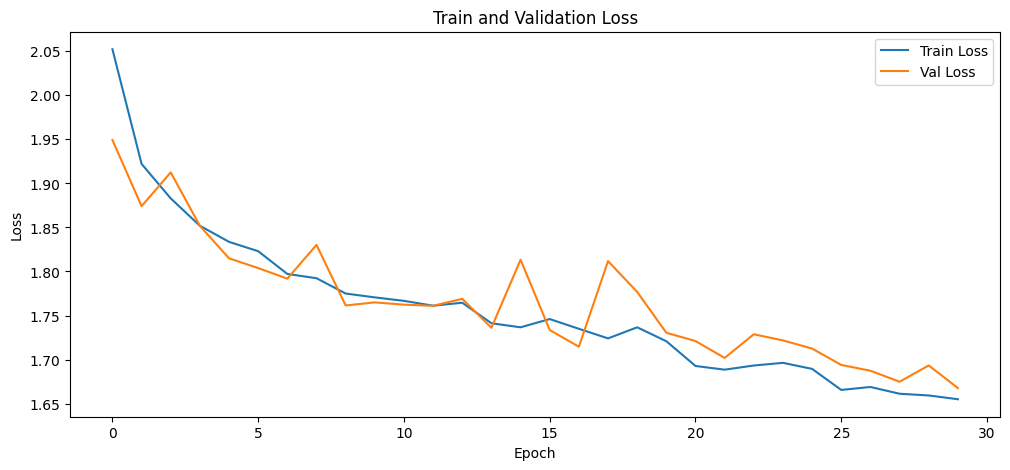

In [53]:
import matplotlib.pyplot as plt
epoch_count = range(len(train_losses))
plt.figure(figsize=(12, 5))
plt.plot(epoch_count, train_losses, label='Train Loss')
plt.plot(epoch_count, val_losses, label='Val Loss')
plt.title("Train and Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

model.eval()
test_loss = 0.0
all_preds = []
all_labels = []

with torch.no_grad():
    for X_test_batch y_test_batch in test_loader:
        X_test_batch = X_test_batch.to(device)
        y_test_batch = y_test_batch.to(device)

        logits, _ = model(X_test_batch)
        loss = criterion(logits, y_test_batch)

        test_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_test_batch.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(classification_report(all_labels, all_preds))

Test Loss: 1.5619
Test Accuracy: 0.3716
Test F1 Score: 0.3159
              precision    recall  f1-score   support

           0       0.41      0.76      0.53       500
           1       0.47      0.33      0.39       500
           2       0.37      0.15      0.21       250
           3       0.34      0.49      0.40       250
           4       0.28      0.14      0.19       250
           5       0.29      0.34      0.31       250
           6       0.33      0.22      0.27       250
           7       0.29      0.18      0.22       250

    accuracy                           0.37      2500
   macro avg       0.35      0.33      0.32      2500
weighted avg       0.37      0.37      0.34      2500



### Trainingsloop mit physics_MA_loss - mit R_E = 1000.0 (N/mm^2)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(np.unique(y_encoded))

model = TransformerModel(input_dim=1,d_model=256,nhead=4,num_layers=2,dropout=0.1,output_dim=num_classes).to(device)

phys_loss_MA = physics_MA_loss().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(list(model.parameters()) + list(phys_loss_MA.parameters()),lr=3e-4,weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

#lambda_phys = 1.0

train_losses = []
val_losses = []
val_f1_scores = []

epochs = 50
for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for X_batch, step_value_batch, _, y_batch in train_loader:
        optimizer.zero_grad()
        X_batch, step_value_batch, y_batch = X_batch.to(device), step_value_batch.to(device), y_batch.to(device)


        class_output, phys_output = model(X_batch)

        class_loss = criterion(class_output, y_batch)
        phys_loss = phys_loss_MA(phys_output, step_value_batch,y_batch)
        loss = class_loss + phys_loss
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_val_batch, step_value_batch, _, y_val_batch in val_loader:
            X_val_batch, step_value_batch, y_val_batch = X_val_batch.to(device), step_value_batch.to(device), y_val_batch.to(device)

            class_output, phys_output = model(X_val_batch)

            class_loss = criterion(class_output, y_val_batch)
            phys_loss = phys_loss_MA(phys_output, step_value_batch, y_val_batch)

            loss = class_loss + phys_loss
            val_loss += loss.item()

            preds = torch.argmax(class_output, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_val_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    f1 = f1_score(all_labels, all_preds, average="macro")
    val_f1_scores.append(f1)

    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val F1 Score: {f1:.4f}")




Epoch 1/50, Train Loss: 2.6565, Val Loss: 2.1165, Val F1 Score: 0.0622
Epoch 2/50, Train Loss: 2.0390, Val Loss: 1.9308, Val F1 Score: 0.1735
Epoch 3/50, Train Loss: 1.9096, Val Loss: 1.8978, Val F1 Score: 0.1758
Epoch 4/50, Train Loss: 1.8494, Val Loss: 1.7950, Val F1 Score: 0.2122
Epoch 5/50, Train Loss: 1.7839, Val Loss: 1.7442, Val F1 Score: 0.2233
Epoch 6/50, Train Loss: 1.7358, Val Loss: 1.7438, Val F1 Score: 0.1932
Epoch 7/50, Train Loss: 1.6798, Val Loss: 1.7810, Val F1 Score: 0.2067
Epoch 8/50, Train Loss: 1.6454, Val Loss: 1.6421, Val F1 Score: 0.2929
Epoch 9/50, Train Loss: 1.6039, Val Loss: 1.6493, Val F1 Score: 0.2746
Epoch 10/50, Train Loss: 1.5827, Val Loss: 1.6333, Val F1 Score: 0.2532
Epoch 11/50, Train Loss: 1.5671, Val Loss: 1.5979, Val F1 Score: 0.2799
Epoch 12/50, Train Loss: 1.5587, Val Loss: 1.6086, Val F1 Score: 0.2761
Epoch 13/50, Train Loss: 1.5445, Val Loss: 1.5786, Val F1 Score: 0.3103
Epoch 14/50, Train Loss: 1.5187, Val Loss: 1.5859, Val F1 Score: 0.2999
E

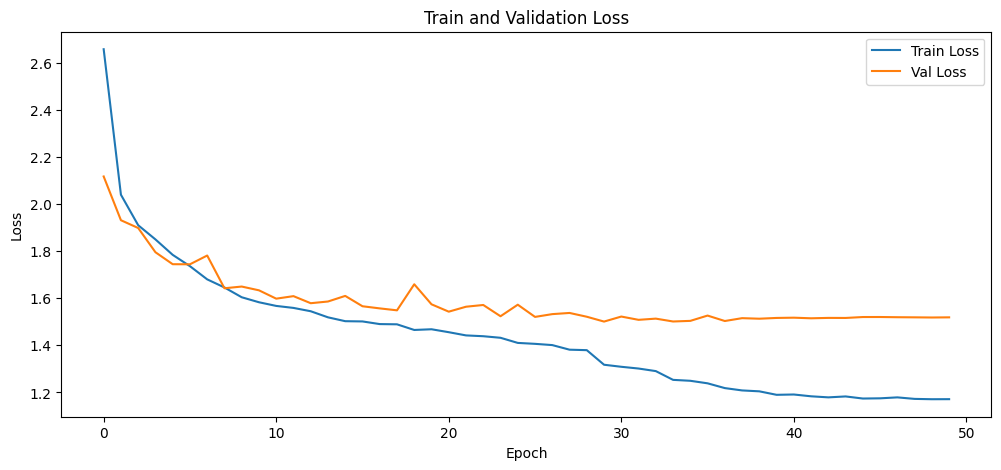

In [12]:
import matplotlib.pyplot as plt
epoch_count = range( len(train_losses))
plt.figure(figsize=(12, 5))
plt.plot(epoch_count, train_losses, label='Train Loss')
plt.plot(epoch_count, val_losses, label='Val Loss')
plt.title("Train and Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

## Train Physics_MA_loss - mit R_E = 1e9

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(np.unique(y_encoded))

model = TransformerModel(input_dim=1,d_model=256,nhead=4,num_layers=2,dropout=0.1,output_dim=num_classes).to(device)

phys_loss_MA = physics_MA_loss().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(list(model.parameters()) + list(phys_loss_MA.parameters()),lr=3e-4,weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

#lambda_phys = 1.0

train_losses = []
val_losses = []
val_f1_scores = []

epochs = 50
for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for X_batch, step_value_batch, y_batch in train_loader:
        optimizer.zero_grad()
        X_batch, step_value_batch, y_batch = X_batch.to(device), step_value_batch.to(device), y_batch.to(device)


        class_output, phys_output = model(X_batch)

        class_loss = criterion(class_output, y_batch)
        phys_loss = phys_loss_MA(phys_output, step_value_batch,y_batch)
        loss = class_loss + phys_loss
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_val_batch, step_value_batch, y_val_batch in val_loader:
            X_val_batch, step_val_batch, y_val_batch = X_val_batch.to(device), step_value_batch.to(device), y_val_batch.to(device)

            class_output, phys_output = model(X_val_batch)

            class_loss = criterion(class_output, y_val_batch)
            phys_loss = phys_loss_MA(phys_output, step_val_batch, y_val_batch)

            loss = class_loss + phys_loss
            val_loss += loss.item()

            preds = torch.argmax(class_output, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_val_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    f1 = f1_score(all_labels, all_preds, average="macro")
    val_f1_scores.append(f1)

    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val F1 Score: {f1:.4f}")




Epoch 1/50, Train Loss: 2.7908, Val Loss: 2.1326, Val F1 Score: 0.0628
Epoch 2/50, Train Loss: 2.0250, Val Loss: 1.9413, Val F1 Score: 0.1855
Epoch 3/50, Train Loss: 1.8450, Val Loss: 1.8155, Val F1 Score: 0.2274
Epoch 4/50, Train Loss: 1.7286, Val Loss: 1.7108, Val F1 Score: 0.2482
Epoch 5/50, Train Loss: 1.6555, Val Loss: 1.6575, Val F1 Score: 0.2424
Epoch 6/50, Train Loss: 1.6240, Val Loss: 1.6179, Val F1 Score: 0.2778
Epoch 7/50, Train Loss: 1.6086, Val Loss: 1.6713, Val F1 Score: 0.2714
Epoch 8/50, Train Loss: 1.5923, Val Loss: 1.6148, Val F1 Score: 0.2531
Epoch 9/50, Train Loss: 1.5740, Val Loss: 1.6264, Val F1 Score: 0.2618
Epoch 10/50, Train Loss: 1.5640, Val Loss: 1.5754, Val F1 Score: 0.2971
Epoch 11/50, Train Loss: 1.5344, Val Loss: 1.5682, Val F1 Score: 0.2832
Epoch 12/50, Train Loss: 1.5274, Val Loss: 1.5774, Val F1 Score: 0.2846
Epoch 13/50, Train Loss: 1.5168, Val Loss: 1.5921, Val F1 Score: 0.2957
Epoch 14/50, Train Loss: 1.5020, Val Loss: 1.5653, Val F1 Score: 0.3020
E

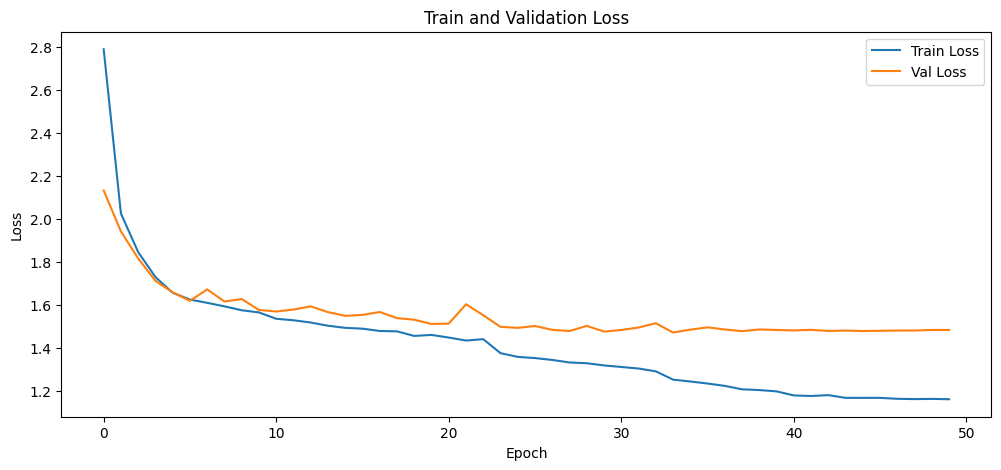

In [34]:
import matplotlib.pyplot as plt
epoch_count = range( len(train_losses))
plt.figure(figsize=(12, 5))
plt.plot(epoch_count, train_losses, label='Train Loss')
plt.plot(epoch_count, val_losses, label='Val Loss')
plt.title("Train and Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

__________________________________________________________________________________________________________________________________ 
__________________________________________________________________________________________________________________________________

## Training für physics_Torque_loss - phasen und angle abhängig \
train_dataset = TensorDataset(X_train_tensor, step_train_tensor, angle_train_tensor, y_train_tensor)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(np.unique(y_encoded))

model = TransformerModel(input_dim=1,d_model=256,nhead=4,num_layers=2,dropout=0.1,output_dim=num_classes).to(device)

phys_loss_Torque = physics_Torque_loss().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(list(model.parameters()) + list(phys_loss_Torque.parameters()),lr=3e-4,weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

#lambda_phys = 1.0

train_losses = []
val_losses = []
val_f1_scores = []

epochs = 50
for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for X_batch, step_value_batch, angle_value_batch, y_batch in train_loader:
        optimizer.zero_grad()
        X_batch, step_value_batch, angle_value_batch, y_batch = X_batch.to(device), step_value_batch.to(device), angle_value_batch.to(device), y_batch.to(device)


        class_output, phys_output = model(X_batch)

        class_loss = criterion(class_output, y_batch)
        phys_loss = phys_loss_Torque(phys_output, step_value_batch, angle_value_batch, y_batch)
        loss = class_loss + phys_loss
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_val_batch, step_val_batch, angle_val_batch, y_val_batch in val_loader:
            X_val_batch, step_val_batch, angle_val_batch, y_val_batch = X_val_batch.to(device), step_val_batch.to(device), angle_val_batch.to(device), y_val_batch.to(device)

            class_output, phys_output = model(X_val_batch)

            class_loss = criterion(class_output, y_val_batch)
            phys_loss = phys_loss_Torque(phys_output, step_val_batch, angle_val_batch, y_val_batch)

            loss = class_loss + phys_loss
            val_loss += loss.item()

            preds = torch.argmax(class_output, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_val_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    f1 = f1_score(all_labels, all_preds, average="macro")
    val_f1_scores.append(f1)

    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val F1 Score: {f1:.4f}")




C:\Users\Patrick\AppData\Local\Temp\ipykernel_15776\34176940.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.d_2 = torch.tensor(self.dm - 0.6495 * self.p, dtype=torch.float32) #


Epoch 1/50, Train Loss: 2.0290, Val Loss: 1.9424, Val F1 Score: 0.1328
Epoch 2/50, Train Loss: 1.8666, Val Loss: 1.7714, Val F1 Score: 0.2092
Epoch 3/50, Train Loss: 1.7327, Val Loss: 1.7071, Val F1 Score: 0.2136
Epoch 4/50, Train Loss: 1.6541, Val Loss: 1.6381, Val F1 Score: 0.2634
Epoch 5/50, Train Loss: 1.6110, Val Loss: 1.6132, Val F1 Score: 0.3253
Epoch 6/50, Train Loss: 1.5872, Val Loss: 1.5772, Val F1 Score: 0.2938
Epoch 7/50, Train Loss: 1.5648, Val Loss: 1.5381, Val F1 Score: 0.3087
Epoch 8/50, Train Loss: 1.5407, Val Loss: 1.5758, Val F1 Score: 0.2946
Epoch 9/50, Train Loss: 1.5250, Val Loss: 1.5156, Val F1 Score: 0.3075
Epoch 10/50, Train Loss: 1.5174, Val Loss: 1.6101, Val F1 Score: 0.2827
Epoch 11/50, Train Loss: 1.4998, Val Loss: 1.5953, Val F1 Score: 0.2912
Epoch 12/50, Train Loss: 1.4972, Val Loss: 1.5281, Val F1 Score: 0.3286
Epoch 13/50, Train Loss: 1.4449, Val Loss: 1.4931, Val F1 Score: 0.3381
Epoch 14/50, Train Loss: 1.4333, Val Loss: 1.4903, Val F1 Score: 0.3273
E

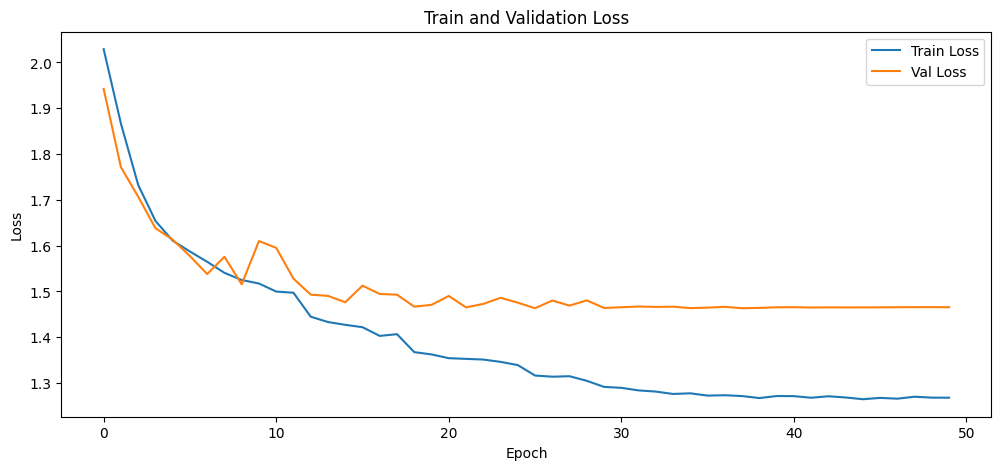

In [14]:
import matplotlib.pyplot as plt
epoch_count = range( len(train_losses))
plt.figure(figsize=(12, 5))
plt.plot(epoch_count, train_losses, label='Train Loss')
plt.plot(epoch_count, val_losses, label='Val Loss')
plt.title("Train and Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [15]:
# ausgeben von mu und k mit (print(model.mu.detach()))
print("mu:", model.mu.detach())
print("k:", model.k.detach())

AttributeError: 'TransformerModel' object has no attribute 'mu'

In [23]:
def pred_filter(fold_results, label="binary", usage1st=True):
    """Auswertung der Fold-Ergebnisse mit Label- und Usage-Filtering (aus deinem Notebook)."""
    metriken = {"Accuracy": [], "Precision": [], "Recall": [], "F1_macro": []}
    if label == "binary":
        average_method = "binary"
    elif label in ["single", "grouped"]:
        average_method = "macro"
    
    for fold in fold_results:
        y_val = fold["True_label"]
        y_pred = fold["Pred_label"]
        usage_val = fold["workpiece_usage"]
        if usage1st == True:
            usage_filter = usage_val == 0
            y_val_filtered = y_val[usage_filter]
            y_pred_filtered = y_pred[usage_filter]
        else:
            y_val_filtered = y_val
            y_pred_filtered = y_pred
        if label == "binary":
            y_val_binary = []
            y_pred_binary = []
            for l in y_val_filtered:
                if str(l).startswith('0'):
                    y_val_binary.append(0)
                else:
                    y_val_binary.append(1)
            for l in y_pred_filtered:
                if str(l).startswith('0'):
                    y_pred_binary.append(0)
                else:
                    y_pred_binary.append(1)
            y_val_filtered = np.array(y_val_binary)
            y_pred_filtered = np.array(y_pred_binary)
        elif label == "grouped":
            y_val_group = []
            y_pred_group = []
            for l in y_val_filtered:
                if str(l).startswith('0'):
                    y_val_group.append(0)
                elif str(l).startswith('1'):
                    y_val_group.append(1)
                elif str(l).startswith('2') or str(l).startswith('3'):
                    y_val_group.append(2)
                elif str(l).startswith('4') or str(l).startswith('5'):
                    y_val_group.append(3)
                elif str(l).startswith('6') or str(l).startswith('7'):
                    y_val_group.append(4)
            for l in y_pred_filtered:
                if str(l).startswith('0'):
                    y_pred_group.append(0)
                elif str(l).startswith('1'):
                    y_pred_group.append(1)
                elif str(l).startswith('2') or str(l).startswith('3'):
                    y_pred_group.append(2)
                elif str(l).startswith('4') or str(l).startswith('5'):
                    y_pred_group.append(3)
                elif str(l).startswith('6') or str(l).startswith('7'):
                    y_pred_group.append(4)
            y_val_filtered = np.array(y_val_group)
            y_pred_filtered = np.array(y_pred_group)
        elif label == "single":
            y_val_filtered = np.array(y_val_filtered)
            y_pred_filtered = np.array(y_pred_filtered)
        metriken["Accuracy"].append(accuracy_score(y_val_filtered, y_pred_filtered))
        metriken["Precision"].append(precision_score(y_val_filtered, y_pred_filtered, average=average_method, zero_division=0))
        metriken["Recall"].append(recall_score(y_val_filtered, y_pred_filtered, average=average_method, zero_division=0))
        metriken["F1_macro"].append(f1_score(y_val_filtered, y_pred_filtered, average=average_method, zero_division=0))
    
    stats = {"Accuracy_mean": np.mean(metriken["Accuracy"]), "Accuracy_std": np.std(metriken["Accuracy"]), "Precision_mean": np.mean(metriken["Precision"]), "Precision_std": np.std(metriken["Precision"]), "Recall_mean": np.mean(metriken["Recall"]), "Recall_std": np.std(metriken["Recall"]), "F1_macro_mean": np.mean(metriken["F1_macro"]), "F1_macro_std": np.std(metriken["F1_macro"])}
    for i in stats:
        if i != "Accuracy_std" and i != "Precision_std" and i != "Recall_std" and i != "F1_macro_std":
            stats[i] *= 100
    df = pd.DataFrame([stats])
    return df

In [20]:
per_class_f1 = f1_score(all_trues, all_preds, average=None)
print(per_class_f1)

[0.53711968 0.39297772 0.35064935 0.46942801 0.32236095 0.19246862
 0.16774194 0.32668329]


### Test nn

In [ ]:
class CNV1dseq(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1, 256, kernel_size=3, padding=1), #wann setzt man batchnorm? man setzt
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes) 
        )
    def forward(self,x):
        x = self.network(x)
        return x 
        

### Unishape model für torque 

# UNISHAPE ZEROSHOT TESTEN - nicht finetuning
Jaaa der randomforest ist korrekt!

In [62]:
import sys
sys.path.append(r"C:\Users\Patrick\UniShape")
from models.unishapemodel_finetune import UniShapeModel


c:\Users\Patrick\miniconda3\envs\thesis_gpu\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [63]:
import sys
sys.path.append(r"C:\Users\Patrick\UniShape")

import torch
import torch.optim as optim
from utils.util import load_pretrained_model


In [167]:
# UniShape will [batch, channels, length]
X_train_tensor = torch.tensor(X_train_scaled.transpose(0, 2, 1), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled.transpose(0,2, 1), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.transpose(0, 2, 1), dtype=torch.float32)

X_train_tensor = torch.tensor(X_train_scaled.transpose(0, 2, 1), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled.transpose(0,2, 1), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.transpose(0, 2, 1), dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [168]:
xb, yb = next(iter(train_loader))
print(xb.shape)

torch.Size([64, 1, 800])


In [169]:

curPath = os.path.abspath(os.path.dirname(__file__))
rootPath = os.path.split(curPath)[0]
sys.path.append(rootPath)

import argparse
import numpy as np
import torch
from torch.utils.data import DataLoader

from utils.util import set_seed, build_dataset_raw_split, load_pretrained_model, evaluate_model, UCRDataset
from datapre.preprocessing import fill_nan_value
from models.unishapemodel_finetune import UniShapeModel
from utils.hyp_batch_shape_sizes import ucr128_hyp_dict_shape_size_batch_size


if __name__ == '__main__': 
    parser = argparse.ArgumentParser()

    parser.add_argument('--random_seed', type=int, default=42, help='shuffle seed')

    parser.add_argument('--dataset', type=str, default='CBF', help='dataset(in ucr)') 
    parser.add_argument('--dataroot', type=str, default='/home/lzhen/UCRArchive_2018', help='path of UCR folder')
    parser.add_argument('--num_class', type=int, default=0, help='number of class')
    parser.add_argument('--input_size', type=int, default=1, help='input_size')

    parser.add_argument('--in_channels', type=int, default=128)
    parser.add_argument('--window_emb_dim', type=int, default=128)
    parser.add_argument('--window_size', type=int, default=16)
    parser.add_argument('--stride', type=int, default=16)
    parser.add_argument('--shape_ratio', type=float, default=0.6)
    parser.add_argument('--scale_len', type=int, default=5) ## 1， 2， 3， 4， 5
    parser.add_argument('--ensemble_num_model', type=int, default=5) ## 1
    parser.add_argument('--pretrain_label_ratio', type=float, default=0.1, help='')

    parser.add_argument('--loss', type=str, default='cross_entropy', help='loss function')
    parser.add_argument('--lr', type=float, default=0.001, help='learning rate')
    parser.add_argument('--weight_decay', type=float, default=0.05, help='weight decay')
    parser.add_argument('--batch_size', type=int, default=512, help='')
    parser.add_argument('--epoch', type=int, default=300, help='training epoch') 
    parser.add_argument('--cuda', type=str, default='cuda:0')

    args = parser.parse_args()

    device = torch.device(args.cuda if torch.cuda.is_available() else "cpu")
    set_seed(args)
    
    train_x, train_target, test_x, test_target, num_classes = build_dataset_raw_split(args)
    args.num_class = num_classes
    if train_x.shape[0] < args.batch_size:
        args.batch_size = train_x.shape[0]

    train_x = train_x[:, :, np.newaxis]
    test_x = test_x[:, :, np.newaxis]

    args.batch_size = ucr128_hyp_dict_shape_size_batch_size[args.dataset]["batch_size"]
    args.scale_len = ucr128_hyp_dict_shape_size_batch_size[args.dataset]["scale_len"]  

    args.num_class = num_classes
    args.seq_len = train_x.shape[1]
    args.model_series_size = train_x.shape[1]
    args.input_size = train_x.shape[2]
    args.out_channels = num_classes
    
    train_dataset, val_dataset, test_dataset = fill_nan_value(train_x, train_x, test_x)
    val_target = train_target

    args.load_checkpoint_path = './pretrained_model_ckpt/unishape_checkpoint_finetune.pth'
    
    model_list = []
    optimizer_list = []  
    for _ in range(args.ensemble_num_model):
        model = UniShapeModel(config=args,
            series_size=args.model_series_size, in_channels=args.in_channels, window_emb_dim=args.window_emb_dim,
            out_channels=args.out_channels, window_size=args.window_size, stride=args.stride, pre_training=False, shape_alpha=0.01, shape_ratio=args.shape_ratio,
            scale_len=args.scale_len
        )
        model = load_pretrained_model(args, model)
        model = model.to(device)
        optimizer = torch.optim.AdamW([{'params': model.parameters()}], lr=args.lr, weight_decay=args.weight_decay)
        model_list.append(model)
        optimizer_list.append(optimizer)

    print('Start finetuning: ')
    train_set = UCRDataset(torch.from_numpy(train_dataset).type(torch.FloatTensor).to(device),
                           torch.from_numpy(train_target).type(torch.FloatTensor).to(device).to(torch.int64))
    val_set = UCRDataset(torch.from_numpy(val_dataset).type(torch.FloatTensor).to(device),
                         torch.from_numpy(val_target).type(torch.FloatTensor).to(device).to(torch.int64))
    test_set = UCRDataset(torch.from_numpy(test_dataset).type(torch.FloatTensor).to(device),
                          torch.from_numpy(test_target).type(torch.FloatTensor).to(device).to(torch.int64))

    train_loader = DataLoader(train_set, batch_size=args.batch_size, num_workers=0, drop_last=False)
    val_loader = DataLoader(val_set, batch_size=args.batch_size, num_workers=0)
    test_loader = DataLoader(test_set, batch_size=args.batch_size, num_workers=0)

    num_steps = train_set.__len__() // args.batch_size + 1
    min_val_loss = float('inf')
    test_accuracy = 0
    
    for epoch in range(args.epoch):
        epoch_train_loss = 0
        num_iterations = 0
        
        for m_j in range(args.ensemble_num_model):
            model_list[m_j].train()
            for x, y in train_loader:
                optimizer_list[m_j].zero_grad()
                pred, step_loss = model_list[m_j](x, y)
                step_loss.backward()
                optimizer_list[m_j].step()
                epoch_train_loss += step_loss.item()
                num_iterations += 1

            epoch_train_loss /= num_steps
     
        for m_j in range(args.ensemble_num_model):
            model_list[m_j].eval()
        
        val_loss, val_accu = evaluate_model(val_loader, model_list, num_classes)
        if min_val_loss > val_loss:
            min_val_loss = val_loss
            end_val_epoch = epoch
            test_loss, test_accuracy = evaluate_model(test_loader, model_list, num_classes)

        if epoch % 50 == 0: 
            print("epoch : {}, train loss: {} , test_accuracy : {}".format(epoch, epoch_train_loss,test_accuracy))

    print("Training end: test_accuracy = ", test_accuracy)
    print('Finish finetuning!')

NameError: name 'os' is not defined

In [170]:
print(X_train_scaled.shape[1])
print(xb.shape[0], xb.shape[1], xb.shape[2])

800
64 1 800


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(np.unique(y_encoded))
class Args:
    pass
args = Args()
args.num_class = num_classes
args.model_series_size = 800
args.in_channels = 128 
args.window_emb_dim = 128
args.shape_ratio = 0.6 # 0.6 default keine ahnung was genau das ist muss ich testen
args.scale_len = 5 # default verstehe ich auch nicht, muss ich testen
args.load_checkpoint_path = r"C:\Users\Patrick\UniShape\pretrained_model_ckpt\unishape_checkpoint_finetune.pth"


model = UniShapeModel(config=args, shape_ratio=args.shape_ratio, scale_len=args.scale_len,series_size=args.model_series_size, in_channels=args.in_channels, window_emb_dim=args.window_emb_dim, out_channels=args.num_class, pre_training=False).to(device)

model = load_pretrained_model(args, model)

C:\Users\Patrick\UniShape\utils\util.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(args.load_checkpoint_path, map_location=f'cuda:0')


In [172]:
xb, yb = next(iter(train_loader))
print("loader batch shape:", xb.shape)

loader batch shape: torch.Size([64, 1, 800])


In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)
train_losses = []
val_losses = []
patience = 5
epochs = 100
counter = 0
best_state = None
best_val_f1 = 0.0
best_epoch = 0

for epoch in range(epochs):
    model.train()
    train_loss_sum = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).long()
        
        if X_batch.shape[1] != 1:
            X_batch = X_batch.permute(0, 2, 1)

        optimizer.zero_grad()
        pred, step_loss = model(X_batch, y_batch)
        step_loss.backward()
        optimizer.step()

        train_loss_sum += step_loss.item()

    avg_train_loss = train_loss_sum / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss_sum = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_val_batch, y_val_batch in val_loader:
            X_val_batch = X_val_batch.to(device)
            y_val_batch = y_val_batch.to(device).long()

            if X_val_batch.shape[1] != 1:
                X_val_batch = X_val_batch.permute(0, 2, 1)
            
            logits, val_loss = model(X_val_batch, y_val_batch)
            val_loss_sum += val_loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_val_batch.cpu().numpy())

    avg_val_loss = val_loss_sum / len(val_loader)
    val_losses.append(avg_val_loss)

    val_f1 = f1_score(all_labels, all_preds, average="macro")
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        counter = 0
        best_state = model.state_dict()
    else:
        counter+= 1
        if counter >= patience:
            print(f"Earlystopping @ epoche {epoch+1}")
            break
    print(f"Epoch {epoch+1}/{epochs} | "f"Train Loss: {avg_train_loss:.4f} | "f"Val Loss: {avg_val_loss:.4f} | "f"Val F1: {val_f1:.4f}")

Epoch 1/100 | Train Loss: 1.6898 | Val Loss: 1.5912 | Val F1: 0.3119
Epoch 2/100 | Train Loss: 1.4887 | Val Loss: 1.5291 | Val F1: 0.3265
Epoch 3/100 | Train Loss: 1.4162 | Val Loss: 1.6112 | Val F1: 0.3273
Epoch 4/100 | Train Loss: 1.3701 | Val Loss: 1.4460 | Val F1: 0.3554
Epoch 5/100 | Train Loss: 1.3281 | Val Loss: 1.4345 | Val F1: 0.3624
Epoch 6/100 | Train Loss: 1.2828 | Val Loss: 1.3431 | Val F1: 0.4263
Epoch 7/100 | Train Loss: 1.2661 | Val Loss: 1.3414 | Val F1: 0.3984
Epoch 8/100 | Train Loss: 1.2330 | Val Loss: 1.4881 | Val F1: 0.3718
Epoch 9/100 | Train Loss: 1.2038 | Val Loss: 1.3292 | Val F1: 0.4206
Epoch 10/100 | Train Loss: 1.1893 | Val Loss: 1.6024 | Val F1: 0.3984
Epoch 11/100 | Train Loss: 1.1634 | Val Loss: 1.3360 | Val F1: 0.4355
Epoch 12/100 | Train Loss: 1.1349 | Val Loss: 1.7762 | Val F1: 0.3273
Epoch 13/100 | Train Loss: 1.1004 | Val Loss: 1.3108 | Val F1: 0.4383
Epoch 14/100 | Train Loss: 1.0809 | Val Loss: 1.3627 | Val F1: 0.4275
Epoch 15/100 | Train Loss: 1.

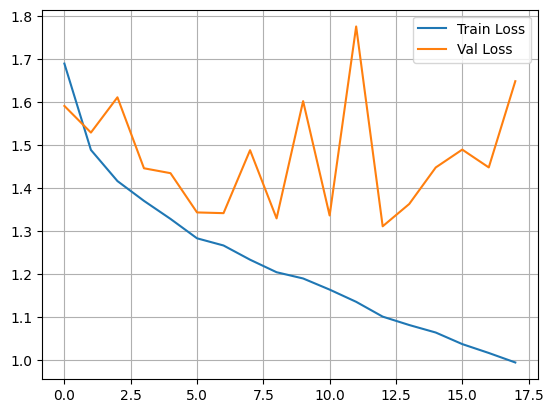

In [174]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.grid(True)
plt.show()

In [131]:
model.load_state_dict(best_state)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_test_batch, y_test_batch in test_loader:
        X_test_batch = X_test_batch.to(device)
        y_test_batch = y_test_batch.to(device)
        if X_test_batch.shape[1] != 1:
            X_test_batch = X_test_batch.permute(0, 2, 1)
        logits, val_loss= model(X_test_batch, y_test_batch)  
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_test_batch.cpu().numpy())

test_f1 = f1_score(all_labels, all_preds, average="macro")
print("Test F1:", test_f1)

Test F1: 0.38539137894811953
